# Project Title: Healthcare Stock Analysis with ESG S-Scores

## Presentation

This notebook analyzes the relationship between healthcare stock returns and ESG (Environmental, Social, and Governance) S-Scores, along with Fama-French factors. We will explore historical stock data, calculate returns, visualize correlations, and perform regression analysis to understand the impact of these variables on stock performance.

## Objective

The primary objective of this project is to investigate whether ESG S-Scores have a significant influence on the risk-adjusted returns of selected healthcare stocks. Additionally, we aim to understand how traditional market factors (Mkt-RF, SMB, HML) interact with ESG metrics in explaining stock performance within the healthcare sector.

## Setup and Library Imports

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

This cell installs the `yfinance` library, which is used to download historical market data. It then imports necessary libraries such as `pandas` for data manipulation, `matplotlib.pyplot` and `seaborn` for plotting, and `statsmodels.formula.api` for statistical modeling.

## Download Historical Stock Data

[*********************100%***********************]  5 of 5 completed


<Axes: title={'center': 'Healthcare Stocks'}, xlabel='Date'>

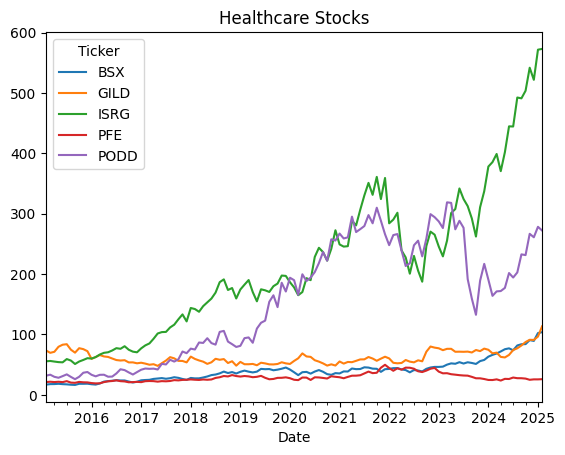

In [ ]:

data=yf.download(['GILD','PODD','BSX','ISRG','PFE'],start="2015-02-01",end="2025-03-01",interval="1mo")['Close']
data.head()
data.plot(title='Healthcare Stocks')

Here, we download historical 'Close' prices for a selection of healthcare stocks (GILD, PODD, BSX, ISRG, PFE) from February 2015 to March 2025, with a monthly interval. The `head()` method displays the first few rows of the downloaded data, and `plot()` visualizes the stock prices over time.

## Calculate Stock Returns

In [ ]:
returns=data.pct_change().dropna()
returns.head()

Ticker,BSX,GILD,ISRG,PFE,PODD
Date,,,,,
2015-03-01,0.050296,-0.052158,0.010060,0.022637,0.051056
2015-04-01,0.003944,0.024254,-0.017920,-0.024720,-0.104947
2015-05-01,0.025253,0.117003,-0.016593,0.024168,-0.052931
2015-06-01,-0.031199,0.042843,-0.006663,-0.027124,0.096215
2015-07-01,-0.020339,0.010309,0.100454,0.075455,0.093579


This cell calculates the monthly percentage change (returns) for each stock based on the downloaded closing prices. The `dropna()` method removes any `NaN` values that result from the `pct_change()` operation (the first month will always be `NaN`).

## Load ESG and Factor Data

In [ ]:
df=pd.read_excel('datiesg.xlsx')

We load an external Excel file named 'datiesg.xlsx' into a pandas DataFrame. This file is expected to contain ESG S-Scores for the healthcare companies and Fama-French factor data (Mkt-RF, SMB, HML, RF), along with individual stock returns.

## Inspect Loaded Data

In [ ]:
df.head()

,DATE,GILD S-Score,PODD S-Score,BSX S-Score,ISRG S-Score,PFE S-Score,Mkt-RF,SMB,HML,RF,BSX,GILD,ISRG,PFE,PODD,BSX-RF,GILD-RF,ISRG-RF,PFE-RF,PODD-RF
0,2015-03-01,61.039228,11.969,50.217475,37.231276,45.534047,-1.11,3.05,-0.38,0.0,0.050296,-0.052159,0.010060,0.022637,0.051056,0.050296,-0.052159,0.010060,0.022637,0.051056
1,2015-04-01,61.179255,11.969,50.730442,37.350216,44.677652,0.59,-2.99,1.80,0.0,0.003944,0.024254,-0.017920,-0.024720,-0.104947,0.003944,0.024254,-0.017920,-0.024720,-0.104947
2,2015-05-01,61.781664,11.969,49.983116,37.350216,45.192554,1.37,0.95,-1.11,0.0,0.025253,0.117003,-0.016593,0.024168,-0.052931,0.025253,0.117003,-0.016593,0.024168,-0.052931
3,2015-06-01,61.534211,11.969,49.412959,37.350216,46.007436,-1.52,2.94,-0.82,0.0,-0.031199,0.042843,-0.006663,-0.027124,0.096215,-0.031199,0.042843,-0.006663,-0.027124,0.096215
4,2015-07-01,60.740452,11.969,49.681269,37.350216,46.604300,1.57,-4.17,-4.16,0.0,-0.020339,0.010309,0.100454,0.075455,0.093579,-0.020339,0.010309,0.100454,0.075455,0.093579


The `df.head()` command is used to display the first five rows of the loaded DataFrame (`df`), allowing for a quick inspection of its structure and content, including ESG scores, Fama-French factors, and stock returns.

## Correlation Matrix Analysis

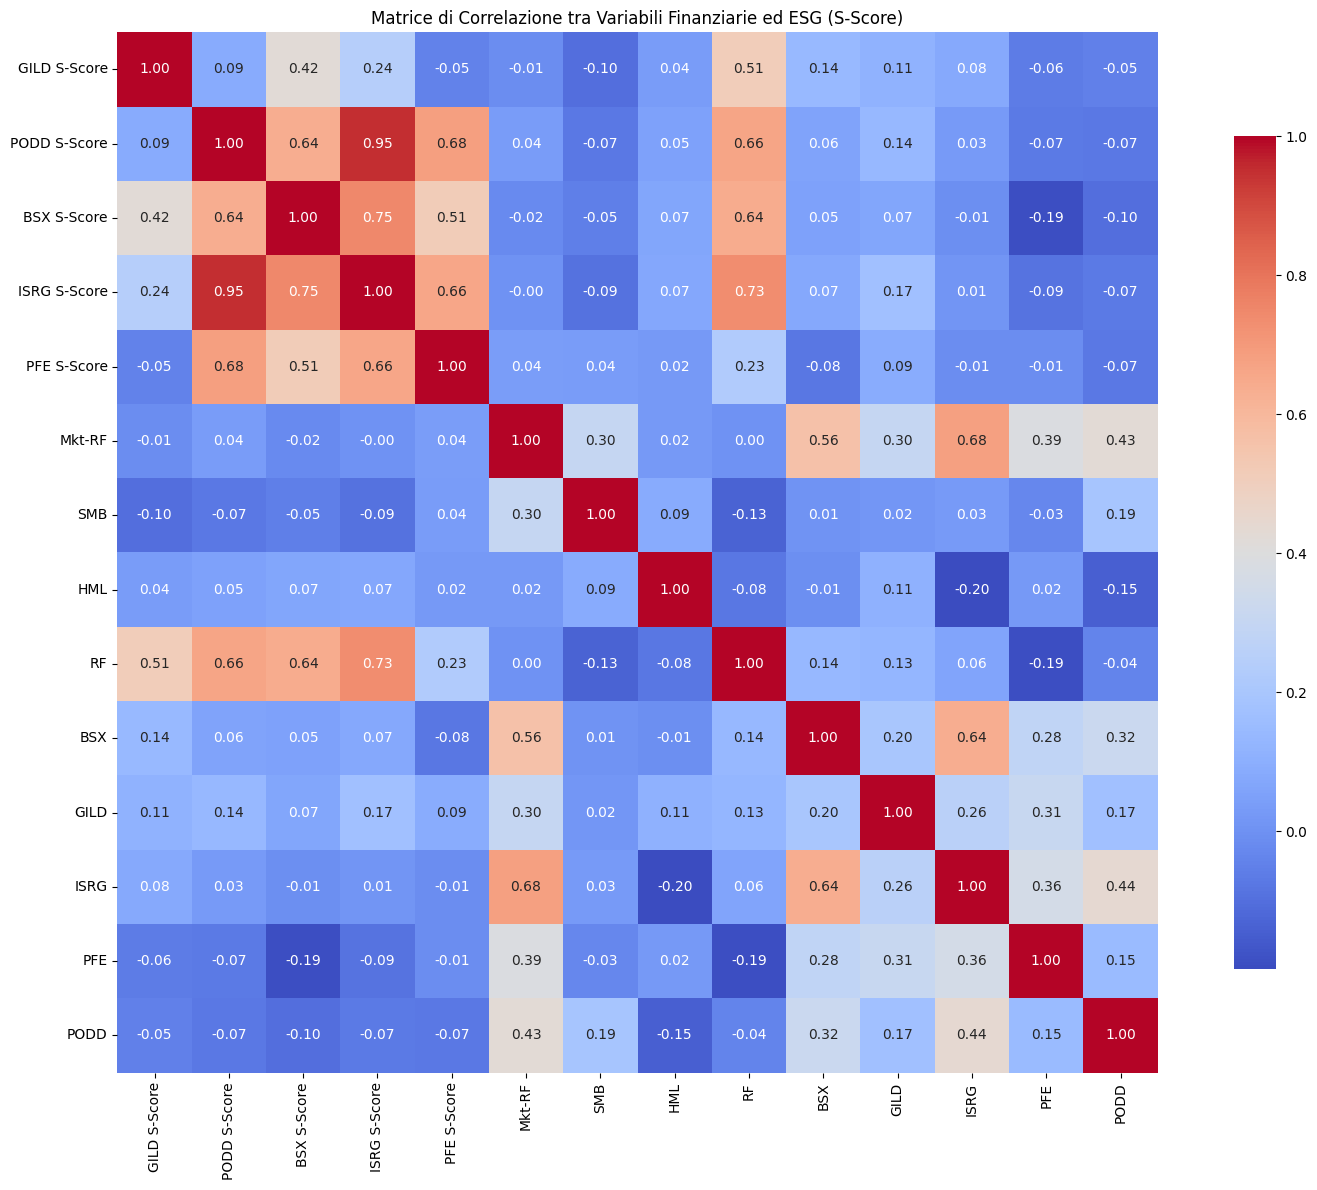

In [ ]:
exclude_columns = ['DATE', 'GILD-RF', 'PODD-RF', 'PFE-RF', 'ISRG-RF', 'BSX-RF']


data_filtered = df.drop(columns=exclude_columns)


corr_matrix = data_filtered.corr()


plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Matrice di Correlazione tra Variabili Finanziarie ed ESG (S-Score)")
plt.tight_layout()

This section prepares the data for correlation analysis. It first defines a list of columns to exclude, then drops these columns from the DataFrame to focus on the variables relevant for correlation. A heatmap is then generated to visualize the correlation matrix between the remaining financial and ESG variables, providing insights into their relationships.

## Regression Analysis with ESG S-Scores and Fama-French Factors

In [ ]:

data_filtered = data_filtered.rename(columns=lambda x: x.replace(" ", "_").replace("-", "_"))


model1 = smf.ols("GILD-RF ~ GILD_S_Score + Mkt_RF + SMB + HML", data=data_filtered).fit()
model2 = smf.ols("PFE-RF ~ PFE_S_Score + Mkt_RF + SMB + HML", data=data_filtered).fit()
model3 = smf.ols("PODD-RF ~ PODD_S_Score + Mkt_RF + SMB + HML", data=data_filtered).fit()
model4 = smf.ols("ISRG-RF ~ ISRG_S_Score + Mkt_RF + SMB + HML", data=data_filtered).fit()
model5 = smf.ols("BSX-RF ~ BSX_S_Score + Mkt_RF + SMB + HML", data=data_filtered).fit()


print(model1.summary())
print(model2.summary())
print(model3.summary())
print(model4.summary())
print(model5.summary())



                            OLS Regression Results                            
Dep. Variable:                   GILD   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     3.890
Date:                Wed, 28 May 2025   Prob (F-statistic):            0.00533
Time:                        12:28:10   Log-Likelihood:                 156.27
No. Observations:                 120   AIC:                            -302.5
Df Residuals:                     115   BIC:                            -288.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.1350      0.114     -1.181   

Before running the regressions, column names in `data_filtered` are cleaned by replacing spaces and hyphens with underscores to ensure they are valid for `statsmodels` formula syntax. Then, Ordinary Least Squares (OLS) regression models are fitted for each healthcare stock. Each model examines the stock's excess return (e.g., `GILD-RF`) as a dependent variable, with the stock's ESG S-Score, and Fama-French factors (Mkt-RF, SMB, HML) as independent variables. The `summary()` method is called for each model to display detailed regression results.